## 🧠 Tarea Semana 3 — Opción Low-Code: Visualizando el Aprendizaje de una CNN con MNIST

### 🎯 Objetivo

Entrenar una red neuronal convolucional (CNN) para clasificar imágenes de dígitos escritos a mano (MNIST), y visualizar qué características aprende cada capa. Al final, se evaluará el modelo con una matriz de confusión y un reporte de clasificación.

## 📦 Parte 1: Definición y entrenamiento del modelo

In [1]:
from tensorflow.keras import Input, Model
from tensorflow.keras import layers

2025-08-28 21:20:32.822886: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Importamos la base de datos MNIST desde Keras

from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255

In [3]:
# Definir la entrada de la red (una imagen de 28x28 en escala de grises)
inputs = Input(shape=(28, 28, 1))   # 👈 CAMBIA AQUÍ alto, ancho, de la imagen

# Primer bloque convolucional: detecta bordes y patrones simples
x = layers.Conv2D(8, (3, 3), activation='relu', name='conv1')(inputs)
x = layers.MaxPooling2D((2, 2))(x)  # Reduce la dimensión y conserva lo más relevante

# Segundo bloque convolucional: detecta combinaciones más complejas (curvas, esquinas)
x = layers.Conv2D(16, (3, 3), activation='relu', name='conv2')(x)
x = layers.MaxPooling2D((2, 2))(x)

# Capa densa para clasificación final
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(10, activation='softmax')(x)  # 👈 CAMBIA AQUÍ a 10, clases posibles (0-9)

# Compilar el modelo
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Mostrar resumen del modelo
print(model.summary())

# Entrenar el modelo por 5 épocas
model.fit(x_train, y_train, epochs=5, validation_split=0.1)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,562 (107.66 KB)

 Trainable params: 27,562 (107.66 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8478 - loss: 0.4881 - val_accuracy: 0.9768 - val_loss: 0.0795
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9712 - loss: 0.0904 - val_accuracy: 0.9802 - val_loss: 0.0693
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.9801 - loss: 0.0630 - val_accuracy: 0.9868 - val_loss: 0.0528
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9859 - loss: 0.0460 - val_accuracy: 0.9848 - val_loss: 0.0580
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9868 - loss: 0.0393 - val_accuracy: 0.9862 - val_loss: 0.0522


### 🧠 Preguntas para reflexionar (Parte 1)

1. ¿Por qué usamos una entrada de tamaño `(28, 28, 1)`? ¿Qué representa cada dimensión?
2. En la primera capa convolucional usamos 8 filtros de tamaño 3×3. ¿Qué significan estos filtros?
3. ¿Qué efecto tiene `MaxPooling2D` sobre la salida de la convolución?
4. ¿Por qué la última capa tiene 10 neuronas y qué significa la función `softmax` en este contexto?
5. Observa el `model.summary()` y explica:

   * ¿Cómo cambia el tamaño del tensor a lo largo de las capas?
   * ¿Por qué disminuyen las dimensiones espaciales?
   * ¿Por qué aumenta el número de filtros?

## 🔍 Parte 2: Visualización de mapas de activación

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


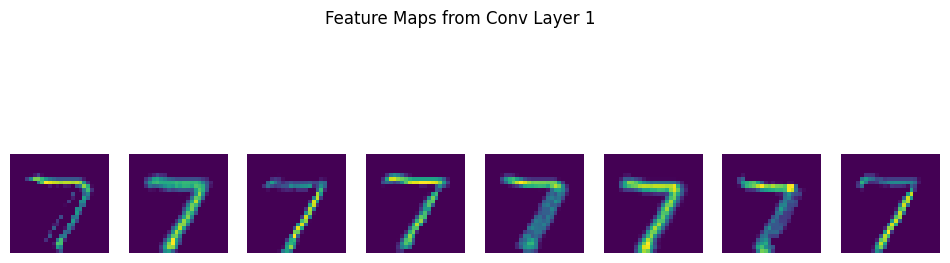

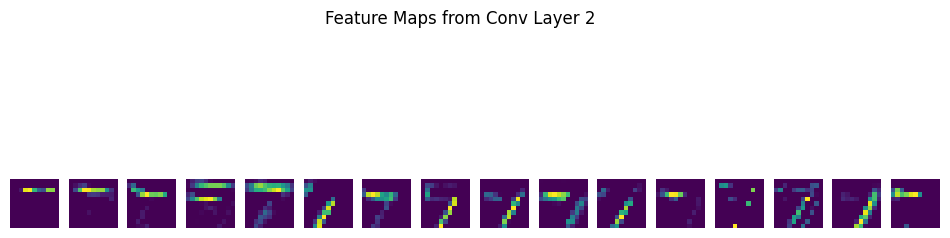

In [4]:

# Seleccionar una imagen del conjunto de prueba
img = x_test[0:1]

# Crear un modelo que devuelva las salidas intermedias de las capas convolucionales
from tensorflow.keras import models
layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
feature_model = models.Model(inputs=model.input, outputs=layer_outputs)

# Obtener los mapas de características
feature_maps = feature_model.predict(img)

# Visualizar los mapas de cada capa
import matplotlib.pyplot as plt

for i, fmap in enumerate(feature_maps):
    num_filters = fmap.shape[-1]
    plt.figure(figsize=(12, 4))
    for j in range(num_filters):
        plt.subplot(1, num_filters, j+1)
        plt.imshow(fmap[0, :, :, j], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f"Feature Maps from Conv Layer {i+1}")
    plt.show()

### 🧠 Pregunta (Parte 2)

> Describe lo que observas en los mapas de características:
>
> * ¿La primera capa detecta bordes o contornos?
> * ¿La segunda capa comienza a detectar formas más complejas como bucles o esquinas?
> * ¿Qué tanto se reduce la imagen con las capas de `MaxPooling`?

## 📊 Parte 3: Evaluación del modelo

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


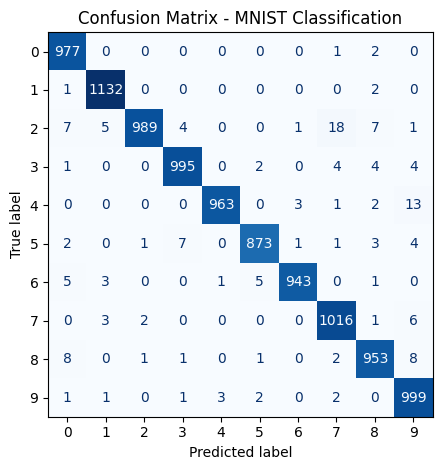

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.96      0.98      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.98      0.98       892
           6       0.99      0.98      0.99       958
           7       0.97      0.99      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.99      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import numpy as np

# Predecir clases
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convertir probabilidades en etiquetas

# Matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap='Blues',
    colorbar=False,
    display_labels=np.arange(10)
)
plt.title("Confusion Matrix - MNIST Classification")
plt.grid(False)
plt.tight_layout()
plt.show()

# Reporte de métricas por clase
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

### 🧠 Preguntas (Parte 3)

1. ¿Qué dígitos fueron más fáciles de clasificar?
2. ¿Dónde se cometieron más errores? ¿En qué clases?
3. ¿Qué métrica destacarías en el reporte (`precision`, `recall`, `f1-score`) y por qué?

## 🧠 Tarea Semana 3: Clasificación de Dígitos con Redes Convolucionales (Informe Ejecutivo)

Esta actividad tiene como objetivo aplicar un modelo de red neuronal convolucional (CNN) para resolver un problema de clasificación de imágenes de dígitos escritos a mano, usando el conjunto de datos **MNIST**. Además de entrenar el modelo, se analizará el proceso de aprendizaje a través de **mapas de activación** y se evaluará su desempeño con una **matriz de confusión** y un **reporte de clasificación**.


## 📝 Instrucciones

### 1. **Definición de arquitectura y entrenamiento del modelo**

Se construyó una red neuronal convolucional que recibe imágenes de tamaño **28×28×1** (escala de grises). La arquitectura incluye:

* Dos capas convolucionales con activación `ReLU`
* Dos capas de reducción espacial con `MaxPooling`
* Una capa densa intermedia
* Una capa de salida con 10 neuronas y `softmax`

📄 **Resumen del modelo**:

```text
input → Conv2D(8 filtros) → MaxPool → Conv2D(16 filtros) → MaxPool → Flatten → Dense(64) → Dense(10)
```

🧩 **Actividad**:

* ¿Por qué la imagen de entrada es de forma `(28, 28, 1)`?
* ¿Qué función cumple la capa `Flatten`?
* ¿Por qué la capa de salida tiene 10 neuronas?
* Explica cómo cambia el tamaño de los datos en cada etapa del modelo.


### 2. **Visualización de mapas de activación**

Se seleccionó una imagen del dígito **7** del conjunto de prueba y se visualizaron los mapas de activación producidos por cada filtro en las dos capas convolucionales.

<img src="https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/cnn_rna_ts3.png" width="900"/>

🧩 **Actividad**:

* ¿Qué tipo de patrones observas en los filtros de la primera capa (Conv1)?
* ¿Qué detectan los filtros de la segunda capa (Conv2)? ¿Cómo se diferencian de la primera?
* ¿Por qué es importante este tipo de visualización para interpretar una CNN?


### 3. **Evaluación del modelo con matriz de confusión**

Después del entrenamiento, se evaluó el modelo usando todo el conjunto de prueba. La siguiente figura muestra la **matriz de confusión** con los resultados obtenidos:

<img src="https://raw.githubusercontent.com/marsgr6/r-scripts/refs/heads/master/imgs/cm_cnn_ts3.png" width="400"/>

🧩 **Actividad**:

* ¿Qué dígitos fueron clasificados correctamente con mayor frecuencia?
* ¿En qué clases se cometieron más errores de confusión?
* ¿Qué implicaciones tiene esto para una posible aplicación práctica?


Después del entrenamiento, se evaluó el modelo CNN con el conjunto de prueba. Se presentan a continuación la **matriz de confusión** y el **reporte de clasificación** por clase, que permiten analizar el desempeño del modelo para cada dígito.

📄 **Reporte de clasificación (conjunto de prueba):**

```
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.99      0.98      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.98      0.99       892
           6       1.00      0.98      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000
```

📊 **Actividad:**

* ¿Qué clases muestran mayor precisión y cuáles presentan errores?
* ¿El modelo tiende a confundir alguna clase específica?
* ¿Cómo interpretarías el valor de **accuracy** y la diferencia entre macro y weighted average?
* ¿Qué importancia tiene el equilibrio entre precisión y recall en este tipo de tareas?
* ¿Qué métricas destacarías para evaluar el modelo?
* ¿Existe alguna clase con peor desempeño? ¿A qué se podría deber?
* ¿Cómo se relaciona el desempeño con la complejidad visual del dígito?


### 5. **Reflexión final**

🧩 **Actividad**:

* ¿Consideras que este modelo convolucional es adecuado para el problema?
* ¿Qué modificaciones propondrías para mejorar el rendimiento?
* ¿Cómo se compara esta arquitectura con una red neuronal multicapa (MLP) tradicional?


⏱️ **Tiempo estimado de desarrollo**: 2 horas
✍️ **Entrega**: Informe ejecutivo con respuestas justificadas y discusión de las visualizaciones presentadas.